# The ±60° WAC_EMP horizontal-line artifact

`docs/proposed-tasks/open-items.md` documents a horizontal line artifact in two `trntest1`
entries' basemaps (`M1314469291CE` at -60.738°N, `M1314314993CE` at -60.6194°N), both sitting
right at ±`ortho_wac_emp.WAC_EMP_MAX_ABS_LATITUDE_DEG` -- the boundary where the WAC_EMP PDS4
archive's equirectangular tile grid (0-60° each hemisphere) hands off to its separate
polar-stereographic tile pair (60-90°). `ortho_wac_emp.reproject_wac_emp_reflectance_to_local_grid`
mosaics the two tile families onto one shared local-Orthographic grid whenever a footprint straddles
that line.

This notebook looks at `ortho_wac_emp.tif` -- the merged reflectance array that mosaic call writes,
*before* any despeckling or Hapke relighting (`hapke.despeckle_and_shade_ortho`, which produces the
hillshade basemap `image_generation.ipynb`/the report gallery actually display). That later shading
step reads per-pixel angles and blends textures in ways that could plausibly hide or reshape a
mosaic-boundary artifact, so it's the wrong place to look for the artifact's origin -- this is the
earliest point the two tile families' pixel values actually land in the same image.

Both files already exist on disk from `trntest1`'s original population run, so this is pure
read-only inspection -- no fetch, no camera build, no ISIS.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.transform import array_bounds
from rasterio.warp import transform as warp_transform
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds as window_from_bounds
from rasterio.windows import transform as window_transform

import trntest
from trntest import cache
from trntest.config import MOON_RADIUS_M
from trntest.geo_utils import geographic_crs, local_orthographic_crs
from trntest.ortho_wac_emp import wac_emp_tile_ids_for_bbox

config = trntest.load_config()
dataset = trntest.TrnTestDataSet.open(config.output_dir / "trntest1", config)

BAD_ENTRIES = ["M1314469291CE", "M1314314993CE"]  # trntest1 indices 201 and 3

## Load the raw mosaic for both known-bad entries

`ortho_wac_emp.tif` has no public accessor -- it's an internal intermediate inside
`dem_ortho.fetch_and_shade_ortho`, one directory level below `entry.dem_ortho_result.ortho` (the
shaded product). Its path is deterministic (`entry.per_image_config.output_dir /
"ortho_wac_emp.tif"`), and `per_image_config` alone (no `camera`, no ISIS) is enough to build it.

In [2]:
rasters = {}
for product_id in BAD_ENTRIES:
    entry = dataset[product_id]
    path = entry.per_image_config.output_dir / "ortho_wac_emp.tif"
    with rasterio.open(path) as src:
        rasters[product_id] = {
            "array": src.read(1),
            "transform": src.transform,
            "crs": src.crs,
            "center_lat_deg": entry.row["center_lat_deg"],
            "center_lon_deg": entry.row["center_lon_deg"],
        }
    print(f"{product_id}: {path}, shape={rasters[product_id]['array'].shape}")

M1314469291CE: /workspace/output/trntest1/_work/M1314469291CE/ortho_wac_emp.tif, shape=(1420, 1480)
M1314314993CE: /workspace/output/trntest1/_work/M1314314993CE/ortho_wac_emp.tif, shape=(1377, 1433)


## Is it nodata?

Nearly none of either array is `NaN` (`reproject_raster_to_local_grid_array`'s nodata convention)
-- both footprints sit safely inside the union of the two tile families' coverage, so there's no
gap for either tile to leave uncovered. Whatever produces the horizontal line, it isn't missing
data.

In [3]:
for product_id, data in rasters.items():
    arr = data["array"]
    n_nan = int(np.isnan(arr).sum())
    print(f"{product_id}: {n_nan} NaN / {arr.size} pixels ({100 * n_nan / arr.size:.4f}%)")

M1314469291CE: 9 NaN / 2101600 pixels (0.0004%)
M1314314993CE: 9 NaN / 1973241 pixels (0.0005%)


## Find the row with the largest row-to-row brightness jump

If the mosaic boundary leaves a real seam, it should show up as an outlier jump in row-mean
reflectance relative to ordinary row-to-row terrain variation elsewhere in the same image.

In [4]:
seam_rows = {}
for product_id, data in rasters.items():
    arr = data["array"]
    row_means = np.nanmean(arr, axis=1)
    diffs = np.abs(np.diff(row_means))
    seam_row = int(np.argmax(diffs))
    seam_rows[product_id] = seam_row
    ranked = np.sort(diffs)[::-1]
    print(
        f"{product_id}: largest jump at row {seam_row}->{seam_row + 1} "
        f"({row_means[seam_row]:.4f} -> {row_means[seam_row + 1]:.4f}, diff={diffs[seam_row]:.4f}); "
        f"next-largest jump elsewhere is {ranked[1]:.4f} ({diffs[seam_row] / ranked[1]:.1f}x smaller)"
    )

M1314469291CE: largest jump at row 555->556 (0.1217 -> 0.1186, diff=0.0031); next-largest jump elsewhere is 0.0025 (1.2x smaller)
M1314314993CE: largest jump at row 570->571 (0.1059 -> 0.1031, diff=0.0029); next-largest jump elsewhere is 0.0010 (2.8x smaller)


## Does that row line up with the ±60° tile boundary?

Converting the seam row's center pixel back to lon/lat via each raster's own embedded
georeferencing.

In [5]:
geo_crs = geographic_crs()
for product_id, data in rasters.items():
    row = seam_rows[product_id]
    width = data["array"].shape[1]
    x, y = data["transform"] * (width / 2, row)
    (lon,), (lat,) = warp_transform(data["crs"], geo_crs, [x], [y])
    print(f"{product_id}: seam row {row} -> lon={lon:.4f}, lat={lat:.4f}")

M1314469291CE: seam row 555 -> lon=145.1333, lat=-60.0003
M1314314993CE: seam row 570 -> lon=168.6087, lat=-59.9991


Both seam rows land within 0.01° of exactly -60°, matching
`ortho_wac_emp.WAC_EMP_MAX_ABS_LATITUDE_DEG` -- this is the equirect/polar tile boundary, not
coincidental terrain contrast.

## Which two tiles actually meet there

`wac_emp_tile_ids_for_bbox` recomputes, from each raster's own bbox/center, exactly which tile IDs
`fetch_wac_emp_reflectance` fetched for it.

In [6]:
tile_ids_by_entry = {}
for product_id, data in rasters.items():
    height, width = data["array"].shape
    bounds = array_bounds(height, width, data["transform"])
    tile_ids = wac_emp_tile_ids_for_bbox(bounds, data["center_lon_deg"], data["center_lat_deg"], MOON_RADIUS_M)
    tile_ids_by_entry[product_id] = tile_ids
    print(f"{product_id}: {tile_ids}")

M1314469291CE: ['WAC_EMP_643NM_P900S0000_304P', 'WAC_EMP_643NM_E300S1350_304P']
M1314314993CE: ['WAC_EMP_643NM_P900S0000_304P', 'WAC_EMP_643NM_E300S1350_304P']


## Visualize: the raw mosaic

The line is a genuine but modest step in mean brightness (a few percent), riding on top of real
per-pixel texture noise of comparable magnitude on both sides -- visible as a faint band across the
frame, not a stripe of missing or saturated pixels.

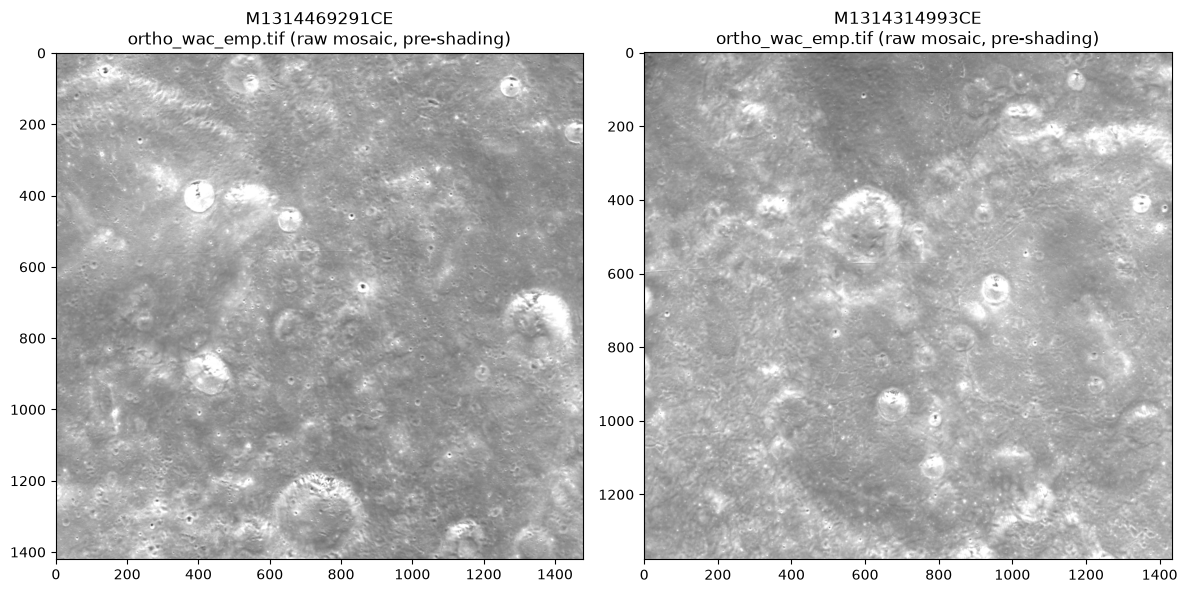

In [7]:
fig, axes = plt.subplots(1, len(rasters), figsize=(6 * len(rasters), 6))
for ax, (product_id, data) in zip(axes, rasters.items(), strict=True):
    arr = data["array"]
    vmax = np.nanpercentile(arr, 99)
    ax.imshow(arr, cmap="gray", vmin=0, vmax=vmax)
    ax.set_title(f"{product_id}\northo_wac_emp.tif (raw mosaic, pre-shading)")
plt.tight_layout()

## Zoom: a 200×200 crop centered on the seam

The full-frame view above is shrunk to fit the figure, which can hide a one-pixel-wide step.
Cropping to the seam's own neighborhood and displaying with nearest-neighbor interpolation (no
smoothing) shows the actual pixel values the step is built from, at full resolution.

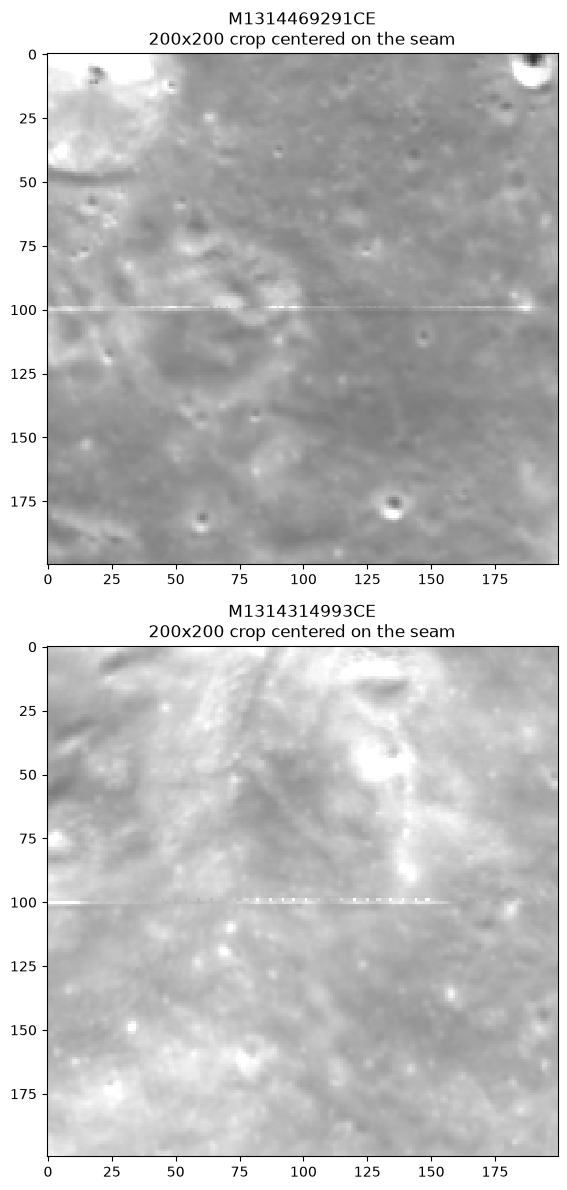

In [8]:
# Stacked vertically, not side by side: each crop already only has 200 pixels of vertical detail
# to show, and halving the figure width to fit two side by side would throw resolution away for
# no reason.
CROP_SIZE = 200
fig, axes = plt.subplots(len(rasters), 1, figsize=(6, 6 * len(rasters)))
for ax, (product_id, data) in zip(axes, rasters.items(), strict=True):
    arr = data["array"]
    height, width = arr.shape
    row0 = seam_rows[product_id] - CROP_SIZE // 2
    col0 = width // 2 - CROP_SIZE // 2
    crop = arr[row0 : row0 + CROP_SIZE, col0 : col0 + CROP_SIZE]
    vmax = np.nanpercentile(crop, 99)
    ax.imshow(crop, cmap="gray", vmin=0, vmax=vmax, interpolation="nearest")
    ax.set_title(f"{product_id}\n{CROP_SIZE}x{CROP_SIZE} crop centered on the seam")
plt.tight_layout()

## Is the step already present in the raw archived tiles?

Everything above looks at `ortho_wac_emp.tif`, which is already our own reprojection of the two
source tiles onto a shared grid. Reading the same footprint directly out of each source tile's own
native pixel grid -- the exact windowed, boundless read
`ortho_wac_emp._reproject_one_wac_emp_tile_to_array` does, before the reprojection step after it --
shows whether the step is already there in the archived products themselves, or only appears once
our own mosaicking combines them.

In [9]:
def _read_native_tile_window(tile_path, dst_bbox_m, center_lon_deg, center_lat_deg, moon_radius_m):
    """Mirrors `_reproject_one_wac_emp_tile_to_array`'s own window computation (including its
    equirect antimeridian-branch-cut fix), stopping short of the `rasterio.warp.reproject` call
    after it. Pixels outside the tile's real raster extent come back as `nodata` (boundless fill) --
    the same value real internal voids carry for a tile with its own embedded nodata (the polar
    tiles) -- so both cases read as "no real data from this tile here" uniformly.
    """
    with rasterio.open(tile_path) as src:
        nodata = src.nodata if src.nodata is not None else float("nan")
        left, bottom, right, top = transform_bounds(
            local_orthographic_crs(center_lon_deg, center_lat_deg, moon_radius_m), src.crs, *dst_bbox_m
        )
        if src.crs.to_dict().get("proj") == "eqc":
            circumference_m = 2 * math.pi * moon_radius_m
            if right < src.bounds.left:
                left, right = left + circumference_m, right + circumference_m
            elif left > src.bounds.right:
                left, right = left - circumference_m, right - circumference_m
        window = window_from_bounds(left, bottom, right, top, transform=src.transform)
        native_transform = window_transform(window, src.transform)
        arr = src.read(1, window=window, boundless=True, fill_value=nodata)
        return arr, native_transform, src.crs, nodata


def _row_latitudes(transform, crs, width, height):
    """Each row's latitude at its center column -- computed by forward-transforming through `crs`
    rather than assumed from row order, since a polar-stereographic tile's row axis isn't
    necessarily north-to-south the way an equirect tile's is."""
    center_col = width / 2
    xs, ys = zip(*(transform * (center_col, row + 0.5) for row in range(height)), strict=True)
    _, lats = warp_transform(crs, geo_crs, xs, ys)
    return np.array(lats)


native_crops = {}
for product_id, data in rasters.items():
    transform = data["transform"]
    width = data["array"].shape[1]
    col0 = width // 2 - CROP_SIZE // 2
    row0 = seam_rows[product_id] - CROP_SIZE // 2
    x0, y_top = transform * (col0, row0)
    x1, y_bottom = transform * (col0 + CROP_SIZE, row0 + CROP_SIZE)
    crop_bbox_m = (min(x0, x1), min(y_bottom, y_top), max(x0, x1), max(y_bottom, y_top))

    # Equirect tile first, polar second -- matches the merged crop's own layout (equirect covers
    # this footprint's less-negative-latitude/"upper" half, polar the more-negative/"lower" half).
    entry_tiles = {}
    for tile_id in sorted(tile_ids_by_entry[product_id], key=lambda t: "P900" in t):
        tile_path = cache.fetch_wac_emp_tile(tile_id, config.cache_root, config.wac_emp_base_url)
        arr, native_transform, native_crs, nodata = _read_native_tile_window(
            tile_path, crop_bbox_m, data["center_lon_deg"], data["center_lat_deg"], MOON_RADIUS_M
        )
        entry_tiles[tile_id] = {"array": arr, "transform": native_transform, "crs": native_crs, "nodata": nodata}
    native_crops[product_id] = entry_tiles

### Visualize: each tile's own native pixels, unresampled

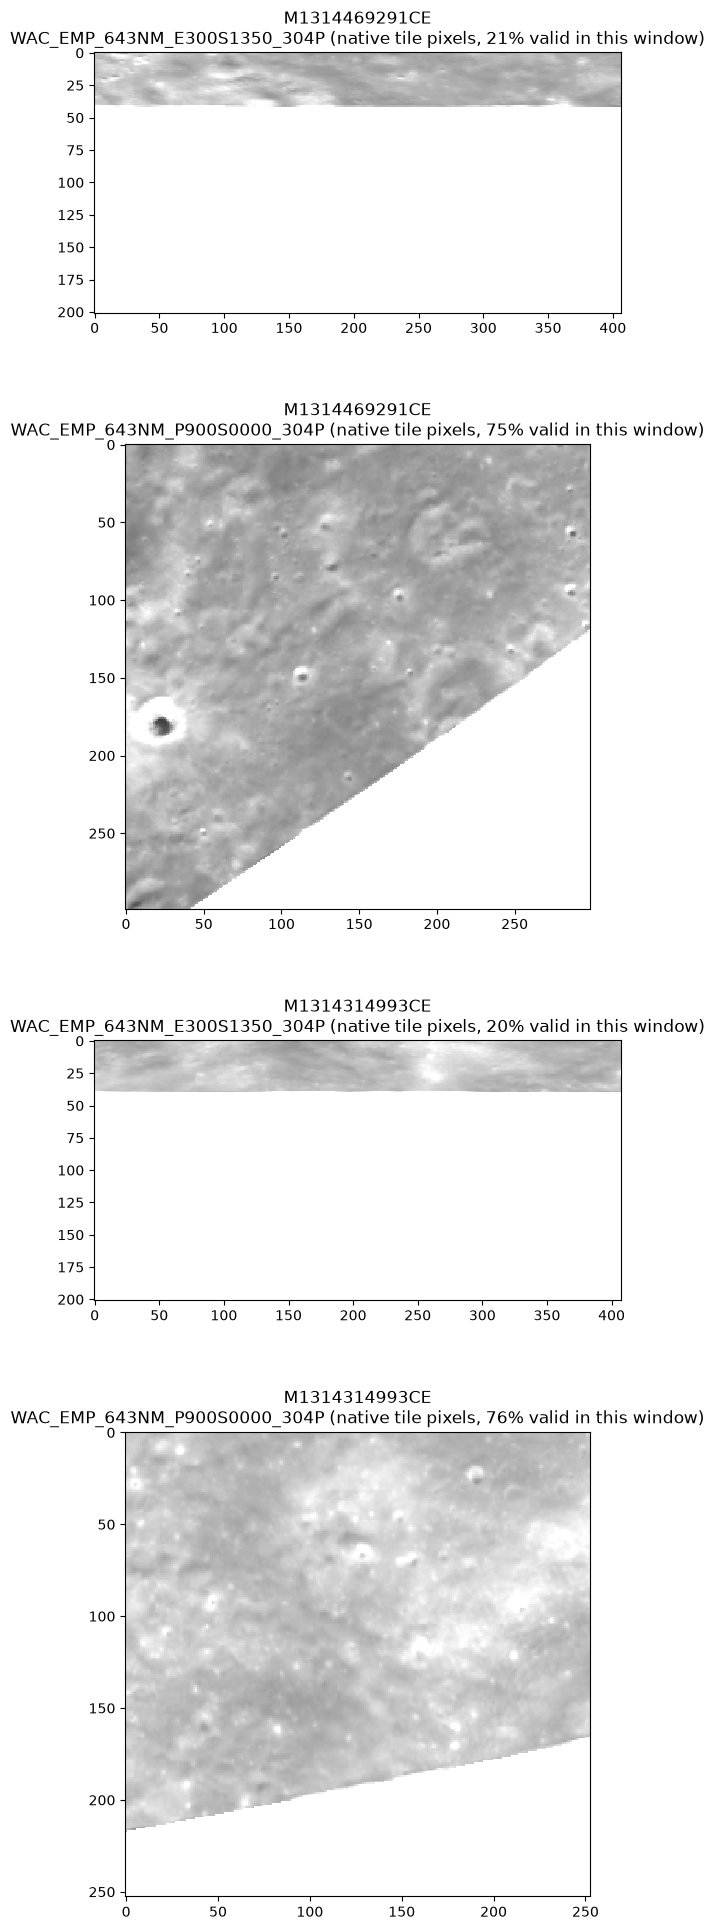

In [10]:
n_tiles_per_entry = len(next(iter(native_crops.values())))
fig, axes = plt.subplots(
    len(native_crops) * n_tiles_per_entry, 1, figsize=(6, 5 * len(native_crops) * n_tiles_per_entry)
)
ax_iter = iter(axes)
for product_id, entry_tiles in native_crops.items():
    for tile_id, t in entry_tiles.items():
        arr = t["array"]
        valid = ~np.isnan(arr) if math.isnan(t["nodata"]) else (arr != t["nodata"])
        vmax = np.nanpercentile(arr[valid], 99) if valid.any() else 1.0
        ax = next(ax_iter)
        ax.imshow(np.where(valid, arr, np.nan), cmap="gray", vmin=0, vmax=vmax, interpolation="nearest")
        ax.set_title(f"{product_id}\n{tile_id} (native tile pixels, {valid.mean() * 100:.0f}% valid in this window)")
plt.tight_layout()

### Do the two tiles' own coverage overlap, or meet at an exact edge?

For each tile, the latitude range its own *valid* pixels span within this same footprint window --
comparing the equirect tile's southernmost valid latitude against the polar tile's northernmost
valid latitude answers whether they overlap, leave a gap, or meet exactly. Each tile's own mean
valid-pixel reflectance in this window is also reported: if it already differs between the two
tiles by roughly the same amount as the step measured in the merged mosaic, the step is a property
of the archived products themselves, not something the mosaicking introduces.

In [11]:
# 304 ppd -> ~0.0033 deg/native-pixel; a "gap"/"overlap" smaller than that is native-resolution
# quantization noise, not a real coverage mismatch.
NATIVE_PIXEL_DEG = 1 / 304
ROW_MAJORITY_VALID_FRACTION = 0.5  # a row counts as "in this tile's coverage" if most of it is

for product_id, entry_tiles in native_crops.items():
    print(product_id)
    ranges = {}
    for tile_id, t in entry_tiles.items():
        arr = t["array"]
        valid = ~np.isnan(arr) if math.isnan(t["nodata"]) else (arr != t["nodata"])
        row_valid_frac = valid.mean(axis=1)
        lats = _row_latitudes(t["transform"], t["crs"], arr.shape[1], arr.shape[0])
        valid_lats = lats[row_valid_frac > ROW_MAJORITY_VALID_FRACTION]
        if len(valid_lats) == 0:
            print(f"  {tile_id}: no valid data in this window")
            continue
        ranges[tile_id] = (valid_lats.min(), valid_lats.max())
        print(
            f"  {tile_id}: valid latitude range = [{valid_lats.min():.4f}, {valid_lats.max():.4f}], "
            f"mean valid reflectance = {arr[valid].mean():.4f}"
        )
    if len(ranges) == n_tiles_per_entry:
        (equirect_id, (eq_lo, eq_hi)), (polar_id, (pol_lo, pol_hi)) = ranges.items()
        overlap_deg = min(eq_hi, pol_hi) - max(eq_lo, pol_lo)
        if abs(overlap_deg) < NATIVE_PIXEL_DEG:
            print(f"  -> exact fit: {overlap_deg:+.4f} deg is under one native pixel ({NATIVE_PIXEL_DEG:.4f} deg)")
        elif overlap_deg > 0:
            print(f"  -> overlap: both tiles have valid data across {overlap_deg:.4f} deg of latitude")
        else:
            print(f"  -> gap: neither tile has valid data across {-overlap_deg:.4f} deg of latitude")

M1314469291CE
  WAC_EMP_643NM_E300S1350_304P: valid latitude range = [-59.9993, -59.8644], mean valid reflectance = 0.1250
  WAC_EMP_643NM_P900S0000_304P: valid latitude range = [-60.5682, -60.0014], mean valid reflectance = 0.1204
  -> exact fit: -0.0021 deg is under one native pixel (0.0033 deg)
M1314314993CE
  WAC_EMP_643NM_E300S1350_304P: valid latitude range = [-60.0010, -59.8727], mean valid reflectance = 0.1052
  WAC_EMP_643NM_P900S0000_304P: valid latitude range = [-60.5817, -60.0032], mean valid reflectance = 0.1041
  -> exact fit: -0.0022 deg is under one native pixel (0.0033 deg)


Both entries land within one native pixel (`NATIVE_PIXEL_DEG` ≈ 0.0033°, i.e. ~100m) of an exact
edge-to-edge fit, no more -- consistent with `docs/data-sources/wac-emp-pds4.md`'s existing note
that the polar tile's own raster edge lands almost exactly on the equirect grid's 60° boundary.

The ~1-4% "mean valid reflectance" difference reported above is an *average over this whole
~0.13°-tall window* -- it can hide a much sharper effect concentrated in just the last valid row or
two right at a tile's own edge. The next section checks that directly.

## Is the equirect tile's own edge row anomalously bright?

Using the same native equirect crop read above, comparing its own last valid row (right at the ±60°
cutoff) against the 10 rows just above it (still well inside the tile's own interior, not the
boundary itself).

In [12]:
for product_id, entry_tiles in native_crops.items():
    equirect_id = next(tile_id for tile_id in entry_tiles if "P900" not in tile_id)
    t = entry_tiles[equirect_id]
    arr = t["array"]
    valid = ~np.isnan(arr) if math.isnan(t["nodata"]) else (arr != t["nodata"])
    row_valid_frac = valid.mean(axis=1)
    valid_rows = np.where(row_valid_frac > ROW_MAJORITY_VALID_FRACTION)[0]
    edge_row = valid_rows.max()  # the row closest to the tile's own southern edge
    interior_rows = valid_rows[-11:-1]  # the 10 rows just above it, excluding the edge itself
    edge_mean = arr[edge_row][valid[edge_row]].mean()
    interior_mean = np.mean([arr[r][valid[r]].mean() for r in interior_rows])
    print(
        f"{product_id} ({equirect_id}): edge row (row {edge_row}) mean = {edge_mean:.4f}, "
        f"interior (10 rows above) mean = {interior_mean:.4f} "
        f"({100 * (edge_mean / interior_mean - 1):+.1f}%)"
    )

M1314469291CE (WAC_EMP_643NM_E300S1350_304P): edge row (row 41) mean = 0.1533, interior (10 rows above) mean = 0.1265 (+21.2%)
M1314314993CE (WAC_EMP_643NM_E300S1350_304P): edge row (row 39) mean = 0.1177, interior (10 rows above) mean = 0.1054 (+11.8%)


The equirect tile's own last valid row -- read directly from the archived `.IMG` file, with no
reprojection, resampling, or mosaicking involved at all -- is dramatically brighter than its own
interior just a few rows away. This is a real edge artifact baked into the archived equirect
product itself, not a broad radiometric offset between the two tile families as a whole: it's
concentrated in the last row or two, not spread evenly across the tile.

## Does the polar tile have an analogous edge artifact?

The equirect check above works because its edge is a fixed native *row* -- easy to isolate.
The polar tile's edge is a *circle* around its own pole at a constant radius, not a row or column,
so a per-longitude probe (radial samples at just this notebook's two footprint longitudes, tried
earlier and found unremarkable) only checks two points on that circle -- if the real effect varies
by longitude, or is only detectable with many samples per radius, two probes can miss it entirely.
Binning **every valid pixel in the whole tile** by its own radius from the pole instead uses the
entire circle (thousands of samples per radius) and doesn't depend on picking the right longitude at
all.

WAC_EMP_643NM_P900S0000_304P: baseline mean (10-35px back from the edge) = 0.1199, near-edge mean (last ~2px) = 0.1263 (+5.3%)


Text(0.5, 1.0, 'WAC_EMP_643NM_P900S0000_304P: radial brightness profile near its own edge')

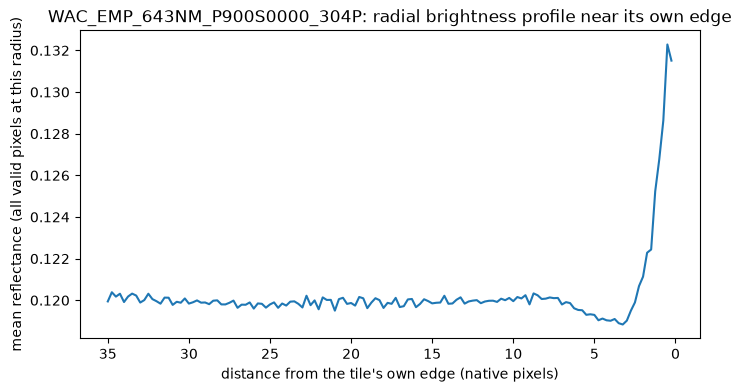

In [13]:
SENTINEL_MAGNITUDE_THRESHOLD = -1e30  # real reflectance is never anywhere near this


def _polar_edge_radial_profile(tile_path, n_bins=140, bin_width_px=0.25):
    """Every valid pixel's mean reflectance, binned by its own distance from the pole, for the last
    `n_bins * bin_width_px` native pixels of radius before the tile's own real coverage ends."""
    with rasterio.open(tile_path) as src:
        height, width = src.height, src.width
        # This tile's own CRS puts the pole (lat=-90) at the projection's own (0, 0) origin --
        # inverting the transform there gives the pole's exact pixel location, without assuming it's
        # exactly (width/2, height/2).
        center_col, center_row = (~src.transform) * (0.0, 0.0)
        arr = src.read(1)
    rows = np.arange(height).reshape(-1, 1) - center_row
    cols = np.arange(width).reshape(1, -1) - center_col
    radius = np.sqrt(rows.astype(np.float32) ** 2 + cols.astype(np.float32) ** 2)
    # A robust catch-all rather than exact equality against the reported `nodata` tag: this tile's
    # real embedded sentinel doesn't always compare equal to that tag bit-for-bit (a PDS3-label
    # precision quirk).
    valid = arr > SENTINEL_MAGNITUDE_THRESHOLD
    max_valid_radius = radius[valid].max()
    bin_edges = max_valid_radius - bin_width_px * np.arange(n_bins, -1, -1)
    bin_idx = np.digitize(radius.ravel(), bin_edges)
    arr_flat, valid_flat = arr.ravel(), valid.ravel()
    means = np.array(
        [
            arr_flat[mask].mean() if (mask := (bin_idx == b) & valid_flat).any() else np.nan
            for b in range(1, len(bin_edges))
        ]
    )
    return bin_edges[:-1], means, max_valid_radius


polar_tile_id = next(tile_id for tile_id in tile_ids_by_entry[BAD_ENTRIES[0]] if "P900" in tile_id)
polar_tile_path = cache.fetch_wac_emp_tile(polar_tile_id, config.cache_root, config.wac_emp_base_url)
radii, means, max_radius = _polar_edge_radial_profile(polar_tile_path)
baseline_mean = np.nanmean(means[:100])  # 10-35 native pixels back from the edge
near_edge_mean = np.nanmean(means[-8:])  # the last 2 native pixels, where the trend is still visible
print(
    f"{polar_tile_id}: baseline mean (10-35px back from the edge) = {baseline_mean:.4f}, "
    f"near-edge mean (last ~2px) = {near_edge_mean:.4f} ({100 * (near_edge_mean / baseline_mean - 1):+.1f}%)"
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(max_radius - radii, means)
ax.set_xlabel("distance from the tile's own edge (native pixels)")
ax.set_ylabel("mean reflectance (all valid pixels at this radius)")
ax.invert_xaxis()
ax.set_title(f"{polar_tile_id}: radial brightness profile near its own edge")

The polar tile **does** brighten near its own edge too, once checked this way -- smaller than the
equirect tile's own effect, but real: flat within noise for the first ~25 native pixels of margin,
then a clear, monotonic rise over the last few pixels before real coverage runs out, backed by
thousands of samples per radius bin even that close to the edge. The per-longitude probes tried
earlier in this notebook missed it -- not because it isn't there, but because they only checked two
points on the boundary circle at coarse radial spacing. Both tiles share a real edge-brightening
artifact near their own ±60° boundary; the earlier claim that this was specific to the equirect tile
was an artifact of an under-powered check on the polar side, not a genuine asymmetry between them.

## Conclusion

Both known-bad entries show a row-mean reflectance jump several times larger than any other
row-to-row jump in the same image, at a row whose latitude matches
`ortho_wac_emp.WAC_EMP_MAX_ABS_LATITUDE_DEG` to within 0.01°. It isn't nodata (both arrays are
essentially fully populated) or an elevation artifact (the DEM comes from a separate, continuous
GLD100 source unaffected by this boundary).

Reading each source tile's own native pixels directly (no reprojection) narrows it further: the
dominant cause is a real edge-brightening artifact in the **equirect tile's own last valid row**,
confirmed directly in the archived `.IMG` file with no reprojection or mosaicking involved --
`reproject_wac_emp_reflectance_to_local_grid`'s bilinear resampling then smears that one bright
native row into a couple of destination rows at the seam, which is what shows up as the visible
bright band in `ortho_wac_emp.tif`. This is sharper than (and corrects) an earlier version of this
analysis, which averaged reflectance over the whole boundary window and reported only a diffuse
~1-4% difference between the two tile families -- that average was real, but it diluted a much
larger, edge-localized spike into what looked like a broad calibration offset.

**The polar tile has the same kind of artifact, smaller but real -- an earlier version of this
notebook missed it.** A per-longitude radial probe (checking just this notebook's two footprint
longitudes) found nothing remarkable and was reported as "no comparable edge spike" -- but that
checked only two points on the polar tile's own boundary *circle*. Binning every valid pixel in the
whole tile by radius from the pole instead (using the entire circle, thousands of samples per
radius) finds a clear, monotonic brightening over the last couple of native pixels before real
coverage ends: +5.3% near the edge vs. 10-35 pixels back from it. Smaller than equirect's own
+21%/+12%, but the same kind of effect, not the asymmetry originally reported.

`notebooks/wac_emp_seam_dem_mosaic.py` cross-checks the mosaicking itself with an independent tool
(ASP `dem_mosaic`) and finds a second, distinct contributor on top of both tiles' own edge
brightening: the polar tile's coverage boundary is a jagged, locally-diagonal line in this
destination grid (visible in the native-pixel crop above), not a clean cut -- so a single
destination row crosses it at scattered, non-contiguous columns, and whichever tile is *not* given
precedence there can flicker in and out of view as a periodic pattern. That notebook also tests one
candidate fix (masking each tile's own bad edge rows before mosaicking) and finds it measurably
helps but isn't sufficient alone -- see its own conclusion.

What remains open is *why* both archived products have this edge artifact in the first place --
that would mean examining USGS/ASU's own tile-production pipeline, which this notebook doesn't
attempt.